In [83]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm
import matplotlib.image as mpimg
from scipy.interpolate import CubicSpline

Start Coordinate (Red): [526 200]
End Coordinate (Green): [111 173]


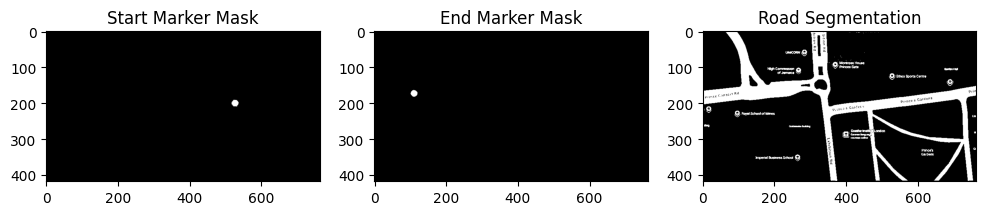

In [84]:
# 1. Load and Preprocess the Image
# The brief specifies using CW2Map.jpg [cite: 1906]
img = mpimg.imread('CW2Map.jpg') 
# Normalize to 0-1 range for easier thresholding
img = img.astype(float) / 255.0

# Extract individual channels
R = img[:, :, 0]
G = img[:, :, 1]
B = img[:, :, 2]

# 2. Identify Markers using Color Masking [cite: 1978]
# Red Marker (Start): High Red, Low Green and Blue
red_mask = (R > 0.7) & (G < 0.4) & (B < 0.4)
# Green Marker (End): High Green, Low Red and Blue
# green_mask = (G > 0.4) & (R < 0.3) & (B < 0.3)
green_mask = (G > 0.6) & (G > R * 1.5) & (G > B * 1.5)

def find_centroid(mask):
    """Calculates the (x, y) center of a binary mask."""
    coords = np.argwhere(mask)
    if len(coords) == 0: return None
    # y is index 0 (rows), x is index 1 (cols)
    return np.mean(coords, axis=0)[::-1].astype(int) # Return (x, y) 

start_pos = find_centroid(red_mask)
end_pos = find_centroid(green_mask)

print(f"Start Coordinate (Red): {start_pos}")
print(f"End Coordinate (Green): {end_pos}")

# 3. Identify Roads using Thresholding 
# Convert to grayscale to isolate the grey paths 
# Road is grey (~0.5 intensity), background is white (~1.0)
gray = 0.299 * R + 0.587 * G + 0.114 * B
road_mask = (gray < 0.85) & (gray > 0.1) # Exclude white background and deep black lines



def convolution(image, kernel, w):
    """
    Manually slides a kernel over an image.
    w is the width of the kernel (assumed to be square and odd)
    """
    img_h, img_w = image.shape
    
    # Create an empty output array of the same size
    output = np.zeros((img_h, img_w))
    
    # We ignore the 1-pixel border to avoid going out of bounds
    # (Padding is a more advanced option, but this is simpler)
    for y in range(1, img_h - 1):
        for x in range(1, img_w - 1):
            # Extract the 3x3 neighborhood
            region = image[y-(w//2):y+(w//2)+1, x-(w//2):x+(w//2)+1]
            # Multiply by kernel and sum
            output[y, x] = np.sum(region * kernel)
            
    return output

def find_edges(image):
    """
    Calculates edge magnitude using manual convolution.
    """
    # Kernels defined in Slide 28 of ComputerVision.pdf
    Kx = np.array([[-1, 0, 1], 
                   [-2, 0, 2], 
                   [-1, 0, 1]])
    
    Ky = np.array([[-1, -2, -1], 
                   [ 0,  0,  0], 
                   [ 1,  2,  1]])
    
    gx = convolution(image, Kx, 3)
    gy = convolution(image, Ky, 3)
    
    # Magnitude of the gradient
    return np.sqrt(gx**2 + gy**2)


road_edges = find_edges(road_mask.astype(float))

# Visualization
plt.figure(figsize=(12, 4))
plt.subplot(131); plt.imshow(red_mask, cmap='gray'); plt.title('Start Marker Mask')
plt.subplot(132); plt.imshow(green_mask, cmap='gray'); plt.title('End Marker Mask')
plt.subplot(133); plt.imshow(road_mask, cmap='gray'); plt.title('Road Segmentation')
plt.show()

In [85]:
blue_mask = (B > 0.6) & (B > R*1.5) & (B > G*1.5)

# 3. Extract all Blue Pixel coordinates
# np.argwhere returns [row, col], so we flip to [x, y]
coords = np.argwhere(blue_mask)
path_points = coords[:, ::-1] 

# 4. Sorting the Path
# Since your path goes mostly East to West (High X to Low X), 
# we sort by X in descending order so the robot starts at the red marker side.
path_points = path_points[path_points[:, 0].argsort()[::-1]]


print(f"Extracted {len(path_points)} via points from your drawing.")

Extracted 17 via points from your drawing.


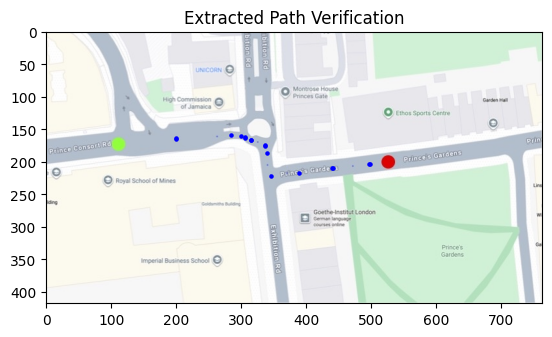

In [86]:
plt.imshow(mpimg.imread('CW2Map.jpg'))
plt.scatter(path_points[:, 0], path_points[:, 1], color='blue', s=5)
plt.title("Extracted Path Verification")
plt.show()

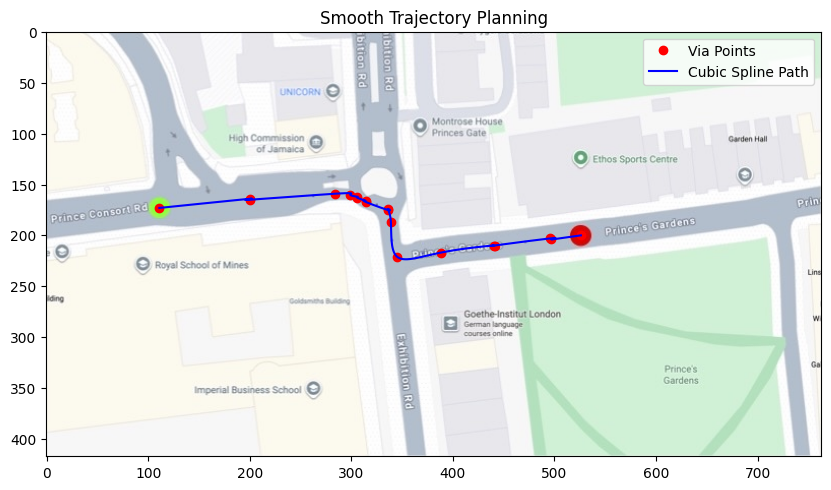

In [87]:
path_points = np.vstack((start_pos, path_points, end_pos))
# 2. Parameterize the path
# We create a 'time' array 'u' based on the number of points
u_nodes = np.linspace(0, 1, len(path_points))
u_fine = np.linspace(0, 1, 300) # 300 points for a super smooth line

# 3. Fit Cubic Splines for X and Y separately
# bc_type='natural' ensures second derivatives are zero at endpoints
cs_x = CubicSpline(u_nodes, path_points[:, 0], bc_type='natural')
cs_y = CubicSpline(u_nodes, path_points[:, 1], bc_type='natural')

# 4. Generate the smooth path
smooth_x = cs_x(u_fine)
smooth_y = cs_y(u_fine)
smooth_path = np.vstack((smooth_x, smooth_y)).T

# 5. Visualization to check against the map
img = plt.imread('CW2Map.jpg')
plt.figure(figsize=(10, 6))
plt.imshow(img)
plt.plot(path_points[:, 0], path_points[:, 1], 'ro', label='Via Points')
plt.plot(smooth_path[:, 0], smooth_path[:, 1], 'b-', label='Cubic Spline Path')
plt.legend()
plt.title("Smooth Trajectory Planning")
plt.show()